In [1]:
!pip install vit-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.5/186.5 kB 6.8 MB/s eta 0:00:00


In [2]:
import torch
from vit_pytorch import ViT
import torch.nn.functional as F
v = ViT(
    image_size = 256,
    patch_size = 32,
    num_classes = 1000,
    dim = 1024,
    depth = 6,
    heads = 16,
    mlp_dim = 2048,
    dropout = 0.1,
    emb_dropout = 0.1
)

img = torch.randn(1, 3, 256, 256)

preds = v(img) # (1, 1000)
print(F.softmax(preds))

tensor([[0.0004, 0.0013, 0.0013, 0.0010, 0.0013, 0.0003, 0.0006, 0.0015, 0.0004,
         0.0010, 0.0024, 0.0012, 0.0007, 0.0009, 0.0002, 0.0009, 0.0015, 0.0009,
         0.0016, 0.0007, 0.0014, 0.0004, 0.0010, 0.0006, 0.0004, 0.0004, 0.0008,
         0.0008, 0.0012, 0.0008, 0.0004, 0.0043, 0.0003, 0.0013, 0.0004, 0.0035,
         0.0010, 0.0007, 0.0011, 0.0006, 0.0021, 0.0009, 0.0006, 0.0004, 0.0011,
         0.0004, 0.0042, 0.0010, 0.0005, 0.0006, 0.0017, 0.0017, 0.0003, 0.0011,
         0.0006, 0.0001, 0.0020, 0.0012, 0.0009, 0.0004, 0.0015, 0.0012, 0.0014,
         0.0006, 0.0007, 0.0007, 0.0009, 0.0004, 0.0004, 0.0012, 0.0004, 0.0007,
         0.0011, 0.0014, 0.0006, 0.0007, 0.0004, 0.0008, 0.0014, 0.0003, 0.0005,
         0.0009, 0.0019, 0.0013, 0.0014, 0.0004, 0.0006, 0.0004, 0.0012, 0.0013,
         0.0007, 0.0014, 0.0010, 0.0013, 0.0012, 0.0007, 0.0012, 0.0009, 0.0007,
         0.0017, 0.0011, 0.0005, 0.0012, 0.0006, 0.0008, 0.0015, 0.0009, 0.0005,
         0.0014, 0.0010, 0.0

/tmp/ipykernel_1455/1577390118.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(preds))


In [3]:
import torch
import torch.nn as nn
#nn就是一些常见的神经网络模块部件
import torch.nn.functional as F
#F代表的是函数，而nn是模块可以放进model，relu,softmax之类的
from torch import optim
#优化器，全称optimizer
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
import matplotlib.pyplot as plt #画图
from tqdm import tqdm

In [4]:
class PatchEmbedding(nn.Module):
  def __init__(self,img_size=224,patch_size=16,in_channels=3,embed_dim=768):
    super().__init__()
    self.img_size=img_size
    self.patch_size=patch_size
    self.n_patches = (img_size//patch_size)**2#这里的是14*14
    self.proj = nn.Conv2d(in_channels=in_channels,out_channels=embed_dim,kernel_size=patch_size,stride=patch_size) #图像到embedding维度的变换

  def forward(self,x):
    x = self.proj(x) #Batch，768，14，14
    x = x.flatten(2) #从第二个维度开始压缩
    x = x.transpose(1,2) #把个数放到前面，dim后
    return x


In [21]:
t = torch.tensor([[1,2],[3,4]])
t = t.flatten(0) #start dimension
print(t)

tensor([1, 2, 3, 4])


In [5]:
class PositionEmbedding(nn.Module):
  def __init__(self,n_patches,embed_dim,dropout=0.1):
    super().__init__()
    self.pos_embed = nn.Parameter(torch.zeros(1,n_patches+1,embed_dim))
    self.dropout = nn.Dropout(dropout)
  def forward(self,x):
    x = x+self.pos_embed #此时的x前面已经加上了cls维度为1的数值,后续会用来作为classify
    x = self.dropout(x)
    return x

In [6]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_dim, num_heads, dropout=0.1):
    super().__init__()
    self.embed_dim = embed_dim
    self.num_heads = num_heads
    self.head_dim = embed_dim // num_heads
    assert self.head_dim * num_heads == embed_dim, "Embedding dimension must be divisible by number of heads"
    self.qkv = nn.Linear(embed_dim, embed_dim * 3)  # 同时计算Q,K,V
    self.attn_dropout = nn.Dropout(dropout)
    self.proj = nn.Linear(embed_dim, embed_dim)
    self.proj_dropout = nn.Dropout(dropout)
    self.scale = self.head_dim ** -0.5
  def forward(self, x):
    batch_size, n_patches, embed_dim = x.shape
    # 计算Q,K,V [batch_size, n_patches, num_heads, head_dim]
    qkv = self.qkv(x).reshape(batch_size, n_patches, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4) #3，B，head，n，dim
    q, k, v = qkv[0], qkv[1], qkv[2]
    # 计算注意力分数 [batch_size, num_heads, n_patches, n_patches]
    attn = (q @ k.transpose(-2, -1)) * self.scale
    attn = attn.softmax(dim=-1)
    attn = self.attn_dropout(attn)
    # 应用注意力权重到V上 [batch_size, num_heads, n_patches, head_dim]
    out = attn @ v
    out = out.transpose(1, 2).reshape(batch_size, n_patches, embed_dim)
    # 线性投影和dropout
    out = self.proj(out)
    out = self.proj_dropout(out)
    return out

In [7]:
class MLP(nn.Module):
  def __init__(self, in_features, hidden_features, out_features, dropout=0.1):
    super().__init__()
    self.fc1 = nn.Linear(in_features, hidden_features)
    self.act = nn.GELU()
    self.fc2 = nn.Linear(hidden_features, out_features)
    self.dropout = nn.Dropout(dropout)
  def forward(self, x):
    x = self.fc1(x)
    x = self.act(x)
    x = self.dropout(x)
    x = self.fc2(x)
    x = self.dropout(x)
    return x

In [8]:
class TransformerBlock(nn.Module):
  def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
    super().__init__()
    self.norm1 = nn.LayerNorm(embed_dim)
    self.attn = MultiHeadAttention(embed_dim, num_heads, dropout)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.mlp = MLP(
    in_features=embed_dim,
    hidden_features=embed_dim * mlp_ratio,
    out_features=embed_dim,
    dropout=dropout
  )
  def forward(self, x):
  # 残差连接和层归一化
    x = x + self.attn(self.norm1(x))
    x = x + self.mlp(self.norm2(x))
    return x

In [9]:
class VisionTransformer(nn.Module):
  def __init__(
  self,
  img_size=224,
  patch_size=16,
  in_channels=3,
  n_classes=1000,
  embed_dim=768,
  depth=12,
  num_heads=12,
  mlp_ratio=4,
  dropout=0.1
  ):
    super().__init__()
    self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
    n_patches = self.patch_embed.n_patches
    # 分类token和位置编码
    self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim)) #适合广播机制
    self.pos_embed = PositionEmbedding(n_patches, embed_dim, dropout)
    # Transformer编码器
    self.blocks = nn.ModuleList([
    TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
    for _ in range(depth)
    ])
    # 分类头
    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Linear(embed_dim, n_classes)
    # 初始化权重
    nn.init.trunc_normal_(self.cls_token, std=0.02) #截断初始化，-2，+2之间
  def forward(self, x):
    batch_size = x.shape[0]
    # 生成patch嵌入
    x = self.patch_embed(x)  # [batch_size, n_patches, embed_dim]
    # 添加class token
    cls_token = self.cls_token.expand(batch_size, -1, -1) #维度必须几乎一致才可以concat
    x = torch.cat([cls_token, x], dim=1)  # [batch_size, n_patches+1, embed_dim]
    # 添加位置编码
    x = self.pos_embed(x)
    # 通过Transformer编码器
    for block in self.blocks:
      x = block(x)
      # 分类
      x = self.norm(x)
    cls_token_final = x[:, 0]  # 只取class token对应的输出
    x = self.head(cls_token_final)
    return x

In [25]:
x = torch.tensor([1])
x=x.expand(6,1) #用于拓展维度和复制
print(x)


tensor([[1],
        [1],
        [1],
        [1],
        [1],
        [1]])


In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0
  for images, labels in tqdm(dataloader, desc="Training"): #description
    images, labels = images.to(device), labels.to(device)
    # 前向传播
    outputs = model(images)
    loss = criterion(outputs, labels)
    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # 统计信息
    running_loss += loss.item()
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item() #eq函数
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
  return epoch_loss, epoch_acc
def evaluate(model, dataloader, criterion, device):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in tqdm(dataloader, desc="Evaluating"):
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      running_loss += loss.item()
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()
      epoch_loss = running_loss / len(dataloader)
      epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [27]:
img_size = 224
patch_size = 16
batch_size = 32
num_epochs = 20
learning_rate = 0.0001
num_classes = 10  # CIFAR-10有10个类别
# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
transform = transforms.Compose([
transforms.Resize((img_size, img_size)),
transforms.ToTensor(),
transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [12:27<00:00, 228kB/s]


In [28]:
model = VisionTransformer(
img_size=img_size,
patch_size=patch_size,
n_classes=num_classes,
embed_dim=768,
depth=1,  # 减少深度以加快训练，simple
num_heads=2
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [29]:
train_losses, train_accs = [], [] #四个list标记loss和acc
test_losses, test_accs = [], []
for epoch in range(num_epochs):
  print(f"Epoch {epoch+1}/{num_epochs}")
  # 训练
  train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  # 评估
  test_loss, test_acc = evaluate(model, test_loader, criterion, device)
  test_losses.append(test_loss)
  test_accs.append(test_acc)
  print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
  print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
  print()

Epoch 1/20


Training:  30%|███       | 472/1563 [01:01<02:22,  7.66it/s]


KeyboardInterrupt: 

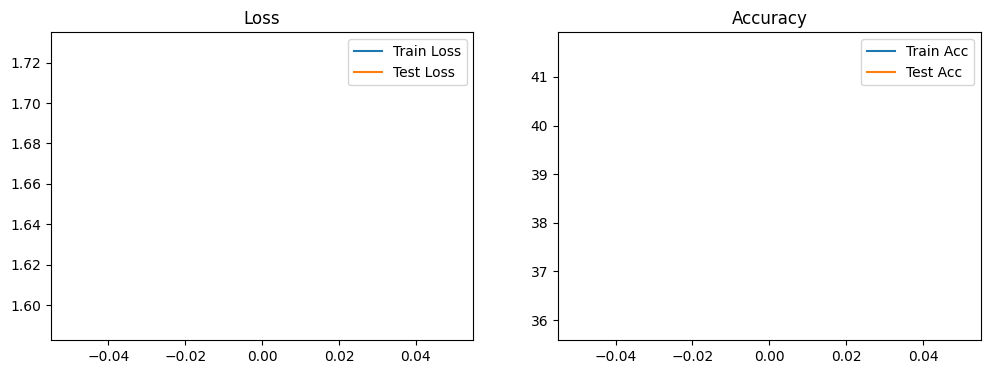

In [15]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.legend()
plt.title('Accuracy')
plt.show()